<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/session11-discussion-1.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Session 11, Part 1 discussion — why does reading both directions help? {.unnumbered}

On the Session 11 page, a bidirectional LSTM labels signal-peptide residues
far better than a forward-only LSTM (MCC 0.820 against 0.631). Work out
**why**, by hand in your group first:

1. Take residue 3 of a signal peptide, in the positively charged
   n-region. What has a **forward** LSTM seen when it labels this residue?
   What has a **backward** LSTM seen? What does a **41-residue window**
   centred on it see? Which of them has seen the hydrophobic h-region,
   the part that actually identifies a signal peptide?
2. Where along a signal peptide do you expect the forward LSTM to make
   most of its mistakes: at the start, in the middle, or near the
   cleavage site? And what about proteins *without* a signal peptide?
3. When would a bidirectional model **not** be possible? (Think of a model
   that writes a protein sequence one residue at a time.)

Then run the cells to check your answers.

In [1]:
import io, os
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

REPO = "https://raw.githubusercontent.com/ElofssonLab/kb8029-book/main/notebooks/data/"
def course_file(name):
    local = os.path.join("data", name)
    return open(local).read() if os.path.exists(local) else requests.get(REPO + name, timeout=60).text

table = pd.read_csv(io.StringIO(course_file("session11-signal-peptides.tsv")), sep="\t",
                    dtype={"sp_start": "Int64", "sp_end": "Int64"})
NTERM_LEN = 70
AA = "ACDEFGHIKLMNPQRSTVWY"
aa_to_idx = {a: i for i, a in enumerate(AA)}
UNK = len(AA)

# the same homology-aware split as the Session 11 notebook (MMseqs2 clusters at 30% identity)
pairs = [l.split("\t") for l in course_file("session11-signal-peptides-mmseqs-30.tsv").strip().split("\n")[1:]]
member_to_rep = {m: r for r, m in pairs}
reps = [member_to_rep.get(a, a) for a in table.accession]
rep_id = {r: i for i, r in enumerate(sorted(set(reps)))}
groups = np.array([rep_id[r] for r in reps])
has_sp = table.sp_end.notna().to_numpy().astype(int)

def homology_split(y, groups, fractions=(0.70, 0.15, 0.15), seed=0):
    rng = np.random.RandomState(seed)
    target = np.outer(fractions, np.bincount(y, minlength=2)); have = np.zeros_like(target); assignment = {}
    for g in rng.permutation(np.unique(groups)):
        counts = np.bincount(y[groups == g], minlength=2)
        deficit = ((target - have) * (counts > 0)).sum(axis=1) / target.sum(axis=1)
        split = int(rng.choice(np.flatnonzero(deficit == deficit.max())))
        assignment[g] = split; have[split] += counts
    split_of = np.array([assignment[g] for g in groups])
    return [np.where(split_of == k)[0] for k in range(3)]

tr_i, va_i, te_i = homology_split(has_sp, groups)

def encode(idx):
    X = np.full((len(idx), NTERM_LEN), UNK, dtype=np.int64)
    Y = np.zeros((len(idx), NTERM_LEN), dtype=np.float32); M = np.zeros_like(Y)
    for n, i in enumerate(idx):
        seq, end = table.sequence[i], table.sp_end[i]
        for j, ch in enumerate(seq[:NTERM_LEN]):
            X[n, j] = aa_to_idx.get(ch, UNK); M[n, j] = 1
            Y[n, j] = 1.0 if pd.notna(end) and j < end else 0.0
    return X, Y, M

data = {k: encode(v) for k, v in [("train", tr_i), ("test", te_i)]}
print(f"train {len(tr_i)} / test {len(te_i)} proteins (homology-aware split)")

train 3432 / test 741 proteins (homology-aware split)


In [2]:
# Question 1: what does each model see when it labels residue i?
row = table.iloc[te_i][table.iloc[te_i].sp_end >= 25].iloc[0]
seq, end = row.sequence[:NTERM_LEN], int(row.sp_end)
i = 2                                         # 0-based: residue 3, in the n-region
show = lambda a, b: seq[max(a, 0):b]
print(f"{row.accession}: signal peptide = residues 1-{end}; we label residue {i + 1} ({seq[i]})\n")
print(f"forward LSTM has seen   : {show(0, i + 1)}")
print(f"backward LSTM has seen  : {' ' * (i)}{show(i, NTERM_LEN)}")
print(f"41-residue window sees  : {' ' * max(i - 20, 0)}{show(i - 20, i + 21)}")
print(f"\n(signal peptide        : {'=' * end}{'.' * (len(seq) - end)})")

Q39487: signal peptide = residues 1-26; we label residue 3 (K)

forward LSTM has seen   : MAK
backward LSTM has seen  :   KLLLFLLPAILGLLVPPRSWSAVALGTNYLLSGQTLETEGHLKNGDFDLVMQDDCNLVLYNGNWQSNT
41-residue window sees  : MAKLLLFLLPAILGLLVPPRSWS

(signal peptide        : ==========================............................................)


**Question 2, predict first.** Now train a forward and a bidirectional
LSTM (8 epochs each, the same settings as in the Session 11 notebook) and
measure, at each position of the first 40 residues, how often each model
mislabels a residue of a signal-peptide protein, and how often it calls a
residue of a protein *without* a signal peptide part of one.

forward LSTM         signal-peptide proteins, residues mislabelled: positions 1-5 0.76, 6-10 0.36, 16-25 0.20;   proteins without one, residues 1-10 called signal peptide 0.118


bidirectional LSTM   signal-peptide proteins, residues mislabelled: positions 1-5 0.12, 6-10 0.08, 16-25 0.23;   proteins without one, residues 1-10 called signal peptide 0.053


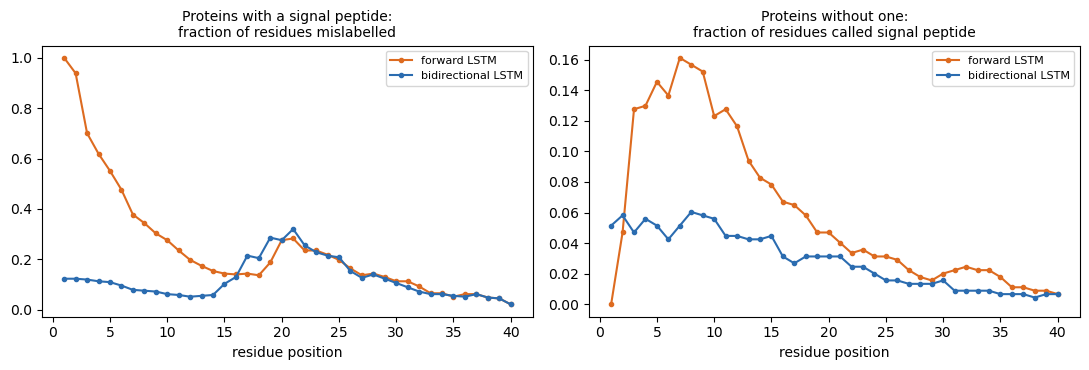

In [3]:
class Tagger(nn.Module):
    def __init__(self, bidirectional):
        super().__init__()
        self.emb = nn.Embedding(len(AA) + 1, 24)
        self.rnn = nn.LSTM(24, 48, batch_first=True, bidirectional=bidirectional)
        self.out = nn.Linear(48 * (2 if bidirectional else 1), 1)
    def forward(self, x):
        h, _ = self.rnn(self.emb(x))
        return self.out(h).squeeze(-1)

def train(bidirectional, epochs=8, seed=0):
    torch.manual_seed(seed)
    model = Tagger(bidirectional); opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    X, Y, M = (torch.from_numpy(a) for a in data["train"])
    loader = DataLoader(TensorDataset(X, Y, M), batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(seed))
    for _ in range(epochs):
        model.train()
        for xb, yb, mb in loader:
            opt.zero_grad()
            loss = (nn.functional.binary_cross_entropy_with_logits(model(xb), yb, reduction="none") * mb).sum() / mb.sum()
            loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        return (torch.sigmoid(model(torch.from_numpy(data["test"][0]))).numpy() >= 0.5).astype(int)

X, Y, M = data["test"]
is_sp = np.array([pd.notna(table.sp_end[i]) for i in te_i])
positions = np.arange(40)
curves = {}
for name, bi in [("forward LSTM", False), ("bidirectional LSTM", True)]:
    pred = train(bi)
    err_sp = np.array([np.mean(pred[is_sp, p][M[is_sp, p] > 0] != Y[is_sp, p][M[is_sp, p] > 0]) for p in positions])
    fp_neg = np.array([np.mean(pred[~is_sp, p][M[~is_sp, p] > 0]) for p in positions])
    curves[name] = (err_sp, fp_neg)
    print(f"{name:20s} signal-peptide proteins, residues mislabelled: positions 1-5 {err_sp[:5].mean():.2f}, "
          f"6-10 {err_sp[5:10].mean():.2f}, 16-25 {err_sp[15:25].mean():.2f};   "
          f"proteins without one, residues 1-10 called signal peptide {fp_neg[:10].mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for name, col in [("forward LSTM", "#dd6b20"), ("bidirectional LSTM", "#2b6cb0")]:
    axes[0].plot(positions + 1, curves[name][0], "o-", ms=3, color=col, label=name)
    axes[1].plot(positions + 1, curves[name][1], "o-", ms=3, color=col, label=name)
axes[0].set_title("Proteins with a signal peptide:\nfraction of residues mislabelled", fontsize=10)
axes[1].set_title("Proteins without one:\nfraction of residues called signal peptide", fontsize=10)
for ax in axes: ax.set_xlabel("residue position"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Discuss.** Compare the curves with your prediction from question 2.
Where is the gap between the two models largest, and why there? At the
N-terminus the forward LSTM has seen almost nothing: whether residue 3
belongs to a signal peptide is decided by the hydrophobic h-region that
comes *after* it. Why is the cleavage site, by contrast, about equally
hard for both models?

**Question 3.** For annotating a protein whose whole sequence is known, a
bidirectional model is fine. A model that *generates* a sequence one
residue at a time cannot look at residues it has not written yet: it must
be causal, reading in one direction only. This is exactly the difference
between BERT-style (bidirectional, masked) and GPT-style (causal,
next-token) language models in Part 2 of the session.

One group presents.